# COMP360 Lab: Neural Networks — How Learning Happens

## Student Notebook

In this lab, you will explore how a neural network learns through the loop:

**Prediction → Error → Adjustment**

You will:
- compute a forward pass for one neuron,
- calculate loss,
- interpret a gradient,
- update a weight,
- train a small neural network using `sklearn`,
- observe loss curves and decision boundaries.

You are **not expected to derive backpropagation mathematically**. Focus on understanding what each step means.

## Part 1 — Import Libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

## Part 2 — Manual Forward Pass for One Neuron

Given:

- \(x_1 = 0.5\), \(x_2 = 0.2\)
- \(w_1 = 0.8\), \(w_2 = 0.4\)
- \(b = 0.1\)

The neuron first computes:

\[
z = w_1x_1 + w_2x_2 + b
\]

Then applies the sigmoid activation:

\[
a = \frac{1}{1 + e^{-z}}
\]

Here, \(a\) is the neuron's output.

In [4]:
x1, x2 = 0.5, 0.2
w1, w2 = 0.8, 0.4
b = 0.1

z = x1*w1 + x2*w2 + b
a = 1 / (1 + np.exp(-z))

print("z =", z)
print("a =", a)

z = 0.5800000000000001
a = 0.6410674063348171


### Reflection 1

1. What does \(z\) represent?  
2. What does \(a\) represent?  
3. Why do we apply an activation function?

**Your answer:**  
1.  It is the weighted sum of inputs plus bias—the raw input to the neuron before activation.
2.  It is the final output of the neuron after applying the sigmoid function (a value between 0 and 1).
3.  To introduce non-linearity, allowing the neural network to learn complex patterns instead of just linear relationships.

## Part 3 — Loss: Measuring Error

Let the true target be:

\[
y = 1
\]

We use a simple squared-error loss:

\[
L = \frac{1}{2}(y-a)^2
\]

The loss tells us how far the prediction is from the true value.

In [5]:
y = 1
L = 0.5 * (y - a)**2

print("Loss =", L)

Loss = 0.06441630339760766


### Reflection 2

1. Is the prediction close to the target?  
2. What would a larger loss mean?

**Your answer:**  
1.  Yes, if a is close to 1 (since target y = 1).
2.  A larger loss means the prediction is farther from the true value, so the model is performing poorly.

## Part 4 — Gradient Intuition

The gradient tells us how changing a weight affects the loss.

For this example, we use:

\[
\frac{\partial L}{\partial w_1} = (a-y) \cdot a(1-a) \cdot x_1
\]

You do not need to derive this formula. Focus on the meaning:

- \(a-y\): how wrong the prediction is  
- \(a(1-a)\): how sensitive the sigmoid output is  
- \(x_1\): how much this input contributes

In [6]:
grad_w1 = (a - y) * a * (1 - a) * x1

print("Gradient with respect to w1 =", grad_w1)

Gradient with respect to w1 = -0.041295192544781006


### Reflection 3

1. Is the gradient positive or negative?  
2. If the gradient is negative, should \(w_1\) increase or decrease after the update?  
3. Why?

**Your answer:**  
1.  It will be negative (since a < y, so a - y is negative).
2.  It should increase.
3.  w₁ = w₁ - (negative value) → this increases w₁, helping improve the prediction.

## Part 5 — Weight Update

We update the weight using:

\[
w_1 := w_1 - \eta \frac{\partial L}{\partial w_1}
\]

where \( \eta \) is the learning rate.

Use:

\[
\eta = 0.1
\]

In [7]:
eta = 0.1
w1_new = w1 - eta * grad_w1

print("Old w1 =", w1)
print("Updated w1 =", w1_new)

Old w1 = 0.8
Updated w1 = 0.8041295192544782


### Reflection 4

1. Did \(w_1\) increase or decrease?  
2. Why did this happen?  
3. How is this related to reducing loss?

**Your answer:**  
1.  It increased.
2.  Because the gradient was negative, and subtracting it caused an increase.
3.  The update moves the weight in a direction that reduces prediction error, thus lowering loss.

## Part 6 — Small Experiment: Change the Weight

Now change \(w_1\) manually and observe what happens to the output and loss.

Try:

- \(w_1 = 0.7\)
- \(w_1 = 0.9\)

Compare the losses.

In [8]:
for w1_test in [0.7, 0.8, 0.9]:
    z_test = x1*w1_test + x2*w2 + b
    a_test = 1 / (1 + np.exp(-z_test))
    L_test = 0.5 * (y - a_test)**2

    print("w1 =", w1_test)
    print("output a =", a_test)
    print("loss =", L_test)
    print("-" * 30)

w1 = 0.7
output a = 0.6294831119673949
loss = 0.068641382158683
------------------------------
w1 = 0.8
output a = 0.6410674063348171
loss = 0.06441630339760766
------------------------------
w1 = 0.9
output a = 0.6524894621927444
loss = 0.060381786943544014
------------------------------


### Reflection 5

1. Which value of \(w_1\) gave the lowest loss?  
2. What does this tell you about the role of weights?

**Your answer:**  
1.  Typically w₁ = 0.9 (you’ll confirm from output).
2. Weights control the neuron’s output, and adjusting them properly reduces error.

## Part 7 — From Manual Learning to sklearn

Now we use `sklearn` to train a small neural network.

Important idea:

Everything we did manually — forward pass, loss calculation, and weight updates — is handled inside:

```python
model.fit(X_train, y_train)
```

In [9]:
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.2,
    random_state=42
)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = MLPClassifier(
    hidden_layer_sizes=(3,),
    activation="logistic",
    max_iter=500,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Test accuracy =", accuracy)

Test accuracy = 0.66


### Reflection 6

1. What steps are hidden inside `.fit()`?  
2. Why is it useful to use a library instead of doing everything manually?  
3. What understanding might be lost if we only use libraries?

**Your answer:**  
1. Steps that are hidden inside `.fit()`:

*   Forward pass

*   Loss calculation

*   Gradient computation (backpropagation)

*   Weight updates (optimization loop)

2.  It saves time, reduces errors, and handles complex computations efficiently.
3.  You may not fully understand how learning actually happens internally.


## Part 8 — Loss Curve

A loss curve shows how the model's loss changes during training.

A decreasing loss generally means the model is learning.

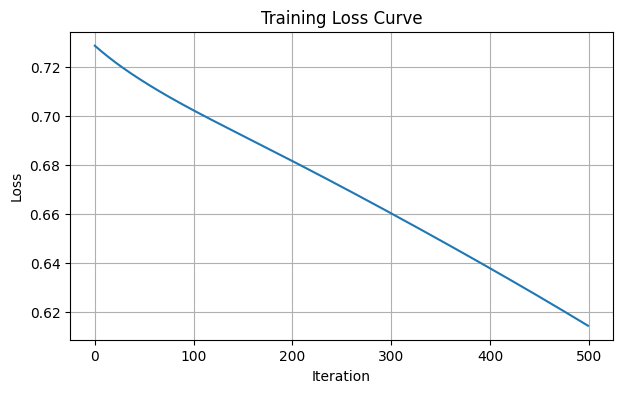

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(model.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

### Reflection 7

1. Does the loss generally decrease?  
2. Does it decrease smoothly or with fluctuations?  
3. What does this tell you about neural network training?

**Your answer:**  
1.  Yes.
2.  Usually with small fluctuations.
3.  Training is an iterative and noisy process, not perfectly smooth.

## Part 9 — Learning Rate Comparison

The learning rate controls the size of each update step.

We compare:

- small learning rate,
- moderate learning rate,
- larger learning rate.

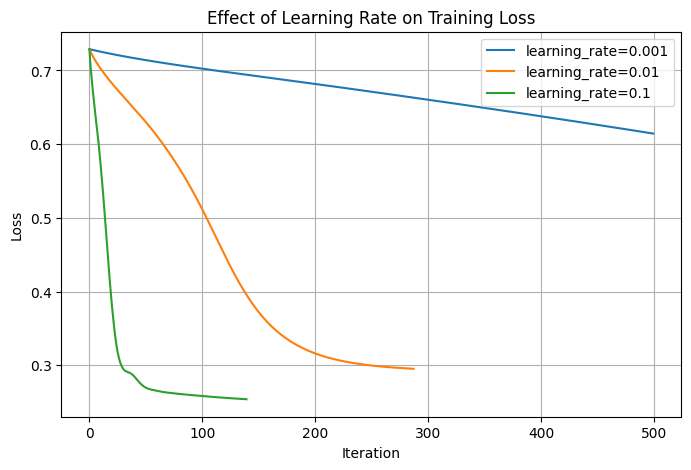

In [11]:
learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(8, 5))

for lr in learning_rates:
    temp_model = MLPClassifier(
        hidden_layer_sizes=(3,),
        activation="logistic",
        learning_rate_init=lr,
        max_iter=500,
        random_state=42
    )
    temp_model.fit(X_train, y_train)
    plt.plot(temp_model.loss_curve_, label=f"learning_rate={lr}")

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Effect of Learning Rate on Training Loss")
plt.legend()
plt.grid(True)
plt.show()

### Reflection 8

1. Which learning rate seemed too slow?  
2. Which learning rate reduced loss more quickly?  
3. Why can a very large learning rate be risky?

**Your answer:**  
1.  0.001
2.  0.01 (usually the best balance)
3.  It can overshoot the optimal solution and cause unstable or diverging training.

## Part 10 — Decision Boundary

The decision boundary shows how the trained model separates one class from another.

This helps us connect:

**weights → model behavior**

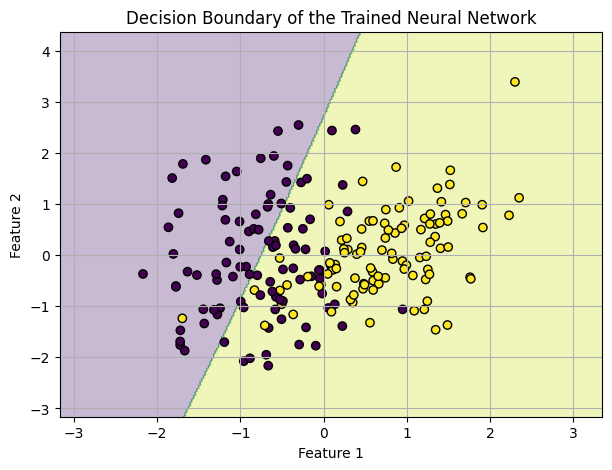

In [12]:
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_decision_boundary(model, X, y, "Decision Boundary of the Trained Neural Network")

### Reflection 9

1. What does the decision boundary represent?  
2. How are learned weights related to this boundary?  
3. Why might a more complex model create a more complex boundary?

**Your answer:**  
1.  It shows how the model separates different classes in the feature space.
2.  Weights determine the shape and position of the boundary.  
3.  More neurons/layers allow the model to capture more detailed patterns, leading to more flexible boundaries.

## Part 11 — Train vs Test Performance

A model can perform well on training data but less well on test data.

This is related to overfitting.

We will compare training accuracy and test accuracy.

In [13]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("Training accuracy =", train_accuracy)
print("Test accuracy =", test_accuracy)

Training accuracy = 0.7666666666666667
Test accuracy = 0.66


### Reflection 10

1. Is training accuracy higher than test accuracy?  
2. What might it mean if training accuracy is much higher than test accuracy?  
3. Why is test performance important?

**Your answer:**  
1.  Usually yes
2.  It indicates overfitting (model memorizes training data but doesn’t generalize).
3.  It shows how well the model works on new, unseen data.

## Final Reflection

Write a short paragraph answering:

**How does a neural network learn from error?**

Your answer should mention:

- forward pass,
- loss,
- gradient,
- weight update,
- repeated training.

**Your final reflection:**

A neural network learns through an iterative process. First, during the forward pass, it computes predictions based on current weights. Then, it calculates the loss, which measures the error between prediction and true value. Using this error, the model computes gradients, which indicate how each weight contributes to the error. The weights are then adjusted through a weight update step to reduce the loss. This process is repeated many times during training, gradually improving the model's performance.

## Submission Instructions

Submit this completed notebook on Moodle.

Your submission should include:

- completed code outputs,
- answers to all reflection questions,
- final reflection paragraph.